# Sleep Health & Sleep Disorder Risk Prediction
## Complete Machine Learning Project

**Project type:** Binary Classification  
**Target:** `sleep_disorder_risk`  
- `0` = Healthy
- `1` = At Risk

This notebook continues the team's existing work and completes the project with:
- Data loading and validation
- EDA and data quality checks
- Target and feature preparation
- Correlation analysis
- Train/test split
- Scaling where required
- Multiple classification models
- Hyperparameter tuning
- Model comparison
- Confusion matrices
- ROC curves and ROC-AUC
- Feature importance
- Final model selection
- Example prediction
- Final conclusions

In [ ]:
# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the dataset

The original project uses `sleep_health_dataset.csv`.



In [ ]:
df=pd.read_csv('sleep_health_dataset.csv')
print(f"Shape: {df.shape}")
df.head()


Dataset loaded from: sleep_health_dataset.csv
Shape: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [ ]:
# ============================================================
# 3. Initial inspection
# ============================================================

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()


Shape: (100000, 32)

Columns:
['person_id', 'age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                   

In [ ]:
# ============================================================
# 4. Missing values and duplicates
# ============================================================

missing = df.isnull().sum().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print("Total missing values:", int(df.isnull().sum().sum()))
if len(missing_nonzero) == 0:
    print("No missing values found.")
else:
    display(missing_nonzero.to_frame("missing_values"))

duplicate_count = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_count)


Total missing values: 0
No missing values found.
Duplicate rows: 0


In [ ]:
# ============================================================
# 5. Descriptive statistics
# ============================================================

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,34.70687,11.036373,18.0,26.0,33.0,42.0,69.0
gender,100000,3,Female,50203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,100000,12,Student,14851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,26.289673,4.479578,16.0,23.2,26.3,29.3,45.0
country,100000,15,USA,20050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_duration_hrs,100000.0,NaN,NaN,NaN,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,NaN,NaN,NaN,4.871144,1.506517,1.0,3.8,4.9,6.0,10.0
rem_percentage,100000.0,NaN,NaN,NaN,20.243968,3.411354,10.0,18.0,20.3,22.6,30.0
deep_sleep_percentage,100000.0,NaN,NaN,NaN,20.253375,4.251096,5.0,17.4,20.3,23.2,30.0


## 3. Understand the original target and gender

The team's original preprocessing removed the `Other` gender category and converted gender to binary.

For the target, the existing project converts the original four categories into a binary problem:

- `Healthy` → `0`
- `Mild`, `Moderate`, `Severe` → `1`

This keeps the project focused on **risk prediction** rather than severity classification.

In [ ]:
# ============================================================
# 6. Original category distributions
# ============================================================

if "gender" in df.columns:
    print("Gender distribution:")
    display(df["gender"].value_counts())

if "sleep_disorder_risk" in df.columns:
    print("Original sleep disorder distribution:")
    display(df["sleep_disorder_risk"].value_counts())


Gender distribution:


,count
gender,
Female,50203
Male,47823
Other,1974


Original sleep disorder distribution:


,count
sleep_disorder_risk,
Healthy,54156
Mild,33479
Moderate,8299
Severe,4066


In [ ]:
# ============================================================
# 7. Clean and prepare the target
# ============================================================

required_columns = {
    "gender",
    "sleep_disorder_risk"
}

missing_required = required_columns - set(df.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Keep the same binary gender treatment used in the team's notebook.
df = df[df["gender"].isin(["Male", "Female"])].copy()

# Encode gender: Female = 0, Male = 1.
df["gender"] = df["gender"].map({"Female": 0, "Male": 1}).astype(int)

# Binary target: Healthy = 0, every disorder-risk category = 1.
df["sleep_disorder_risk"] = (
    df["sleep_disorder_risk"] != "Healthy"
).astype(int)

df.reset_index(drop=True, inplace=True)

print("Shape after removing the 'Other' gender category:", df.shape)
print("\nGender:")
print(df["gender"].value_counts())

print("\nBinary target:")
print(df["sleep_disorder_risk"].value_counts())


Shape after removing the 'Other' gender category: (98026, 32)

Gender:
gender
0    50203
1    47823
Name: count, dtype: int64

Binary target:
sleep_disorder_risk
0    53093
1    44933
Name: count, dtype: int64


## 4. Feature selection

The original project removed identifier, categorical, and several auxiliary columns before modeling.

We keep that feature set so the final notebook remains consistent with the team's current project rather than silently changing its problem definition.

In [ ]:
# ============================================================
# 8. Feature selection — consistent with the team's notebook
# ============================================================

columns_to_drop = [
    "person_id",
    "occupation",
    "country",
    "sleep_quality_score",
    "alcohol_units_before_bed",
    "work_hours_that_day",
    "felt_rested",
    "chronotype",
    "mental_health_condition",
    "sleep_aid_used",
    "room_temperature_celsius",
    "season",
    "day_type",
    "weekend_sleep_diff_hrs",
    "cognitive_performance_score",
]

existing_to_drop = [c for c in columns_to_drop if c in df.columns]
df_model = df.drop(columns=existing_to_drop).copy()

print("Dropped columns:")
print(existing_to_drop)

print("\nFinal modeling columns:")
print(df_model.columns.tolist())

print("\nFinal shape:", df_model.shape)
display(df_model.head())


Dropped columns:
['person_id', 'occupation', 'country', 'sleep_quality_score', 'alcohol_units_before_bed', 'work_hours_that_day', 'felt_rested', 'chronotype', 'mental_health_condition', 'sleep_aid_used', 'room_temperature_celsius', 'season', 'day_type', 'weekend_sleep_diff_hrs', 'cognitive_performance_score']

Final modeling columns:
['age', 'gender', 'bmi', 'sleep_duration_hrs', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'heart_rate_resting_bpm', 'shift_work', 'sleep_disorder_risk']

Final shape: (98026, 17)


,age,gender,bmi,sleep_duration_hrs,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,heart_rate_resting_bpm,shift_work,sleep_disorder_risk
0,29,0,25.7,6.19,22.5,19.3,16,3,0,32,0,6592,0,4.4,63,0,0
1,55,0,22.0,8.32,26.9,14.9,17,4,0,33,1,10111,8,4.0,52,0,0
2,42,1,25.0,3.74,20.2,16.2,26,4,0,89,1,9222,28,7.8,72,1,1
3,37,0,29.5,6.79,17.7,17.7,13,4,0,52,1,9190,40,4.9,71,0,0
4,23,1,23.6,5.02,23.3,18.3,30,5,40,72,0,4273,0,7.4,71,0,1


### Why are these columns removed?

- `person_id`: identifier, not a meaningful predictive feature.
- `occupation`, `country`, `chronotype`, `mental_health_condition`, `season`, `day_type`: categorical variables that were excluded in the team's current feature set.
- `sleep_quality_score`, `felt_rested`, `cognitive_performance_score`: auxiliary sleep/well-being measures excluded by the team's current preprocessing.
- `alcohol_units_before_bed`, `work_hours_that_day`, `sleep_aid_used`, `room_temperature_celsius`, `weekend_sleep_diff_hrs`: excluded to keep the final feature space consistent with the team's existing notebook.

This is a project-design decision, not a claim that every removed feature is universally useless.

In [ ]:
# ============================================================
# 9. Check the prepared data
# ============================================================

print("Missing values after preprocessing:",
      int(df_model.isnull().sum().sum()))
print("Duplicate rows after preprocessing:",
      int(df_model.duplicated().sum()))

print("\nData types:")
display(df_model.dtypes.to_frame("dtype"))

print("\nTarget distribution:")
target_counts = df_model["sleep_disorder_risk"].value_counts().sort_index()
display(target_counts.to_frame("count"))

target_percent = (
    df_model["sleep_disorder_risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
display(target_percent.to_frame("percentage"))


Missing values after preprocessing: 0
Duplicate rows after preprocessing: 0

Data types:


,dtype
age,int64
gender,int64
bmi,float64
sleep_duration_hrs,float64
rem_percentage,float64
deep_sleep_percentage,float64
sleep_latency_mins,int64
wake_episodes_per_night,int64
caffeine_mg_before_bed,int64
screen_time_before_bed_mins,int64



Target distribution:


,count
sleep_disorder_risk,
0,53093
1,44933


,percentage
sleep_disorder_risk,
0,54.16
1,45.84


## 5. Exploratory Data Analysis

The next plots answer practical questions about the dataset before training:
- How balanced is the target?
- How does risk vary with age?
- What happens across BMI?
- How does sleep duration relate to risk?
- Does stress differ between groups?
- Does screen time before bed differ between groups?

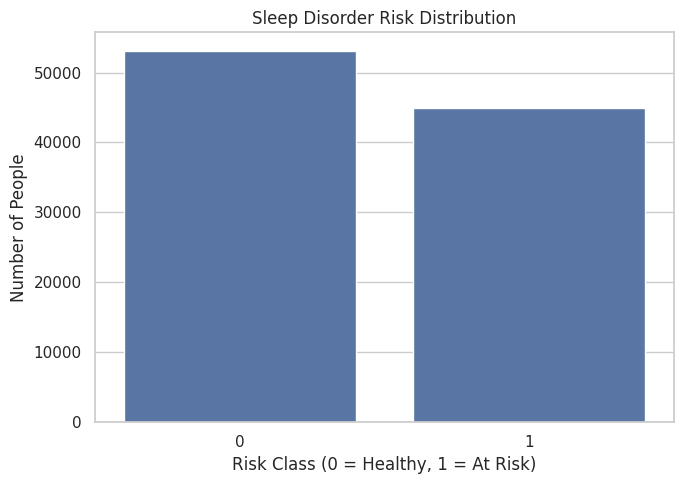

In [ ]:
# ============================================================
# 10. Target distribution
# ============================================================

plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_model,
    x="sleep_disorder_risk",
    order=[0, 1]
)
plt.title("Sleep Disorder Risk Distribution")
plt.xlabel("Risk Class (0 = Healthy, 1 = At Risk)")
plt.ylabel("Number of People")
plt.tight_layout()
plt.show()


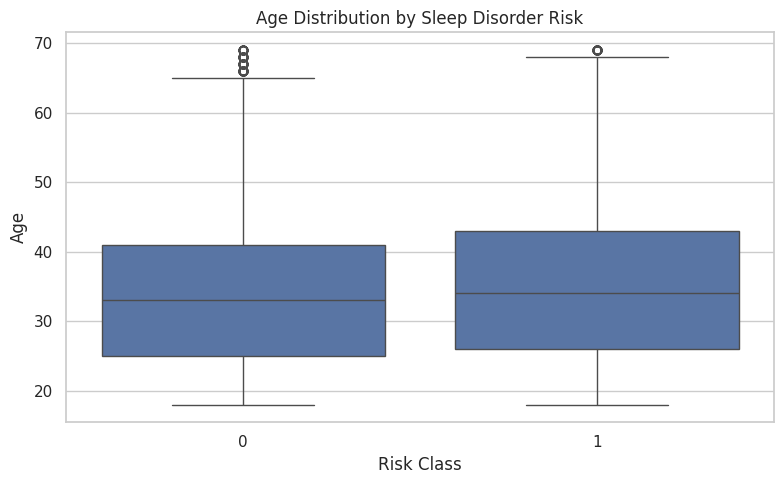

In [ ]:
# ============================================================
# 11. Age distribution by target
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_model,
    x="sleep_disorder_risk",
    y="age"
)
plt.title("Age Distribution by Sleep Disorder Risk")
plt.xlabel("Risk Class")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


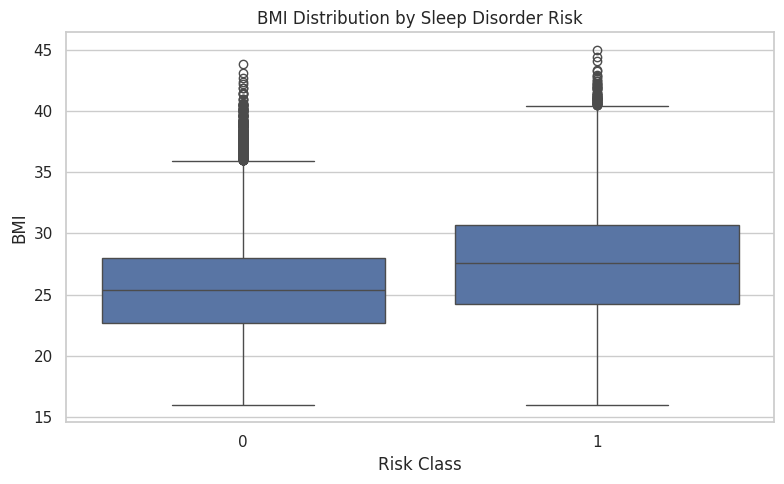

In [ ]:
# ============================================================
# 12. BMI distribution by target
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_model,
    x="sleep_disorder_risk",
    y="bmi"
)
plt.title("BMI Distribution by Sleep Disorder Risk")
plt.xlabel("Risk Class")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()


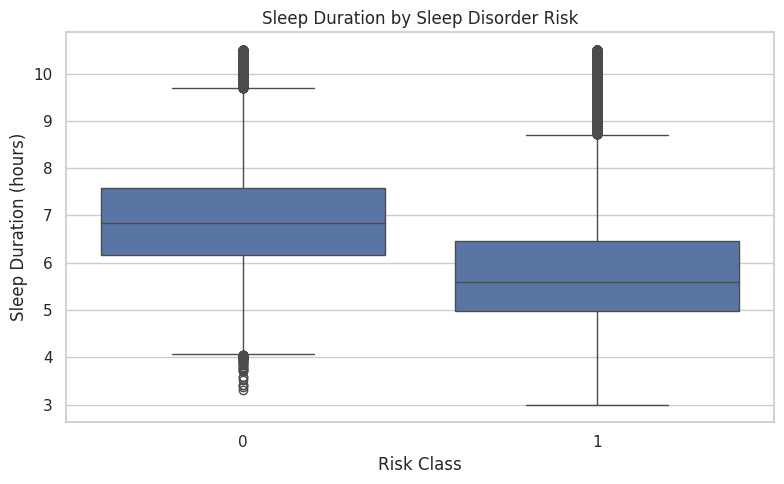

In [ ]:
# ============================================================
# 13. Sleep duration by target
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_model,
    x="sleep_disorder_risk",
    y="sleep_duration_hrs"
)
plt.title("Sleep Duration by Sleep Disorder Risk")
plt.xlabel("Risk Class")
plt.ylabel("Sleep Duration (hours)")
plt.tight_layout()
plt.show()


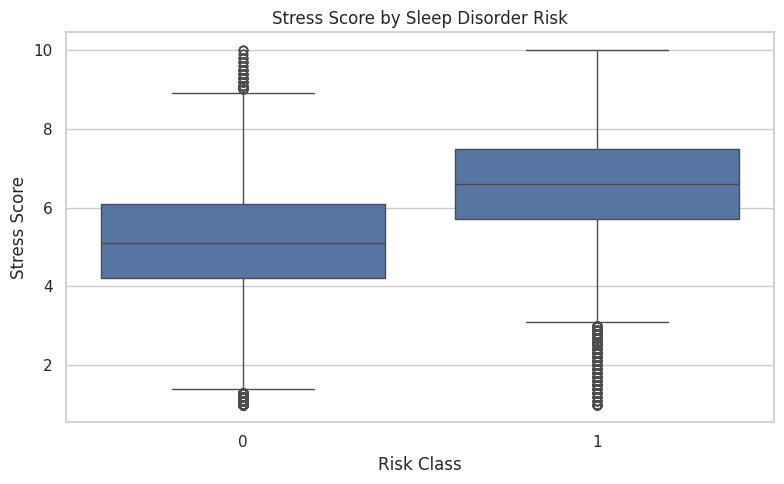

In [ ]:
# ============================================================
# 14. Stress score by target
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_model,
    x="sleep_disorder_risk",
    y="stress_score"
)
plt.title("Stress Score by Sleep Disorder Risk")
plt.xlabel("Risk Class")
plt.ylabel("Stress Score")
plt.tight_layout()
plt.show()


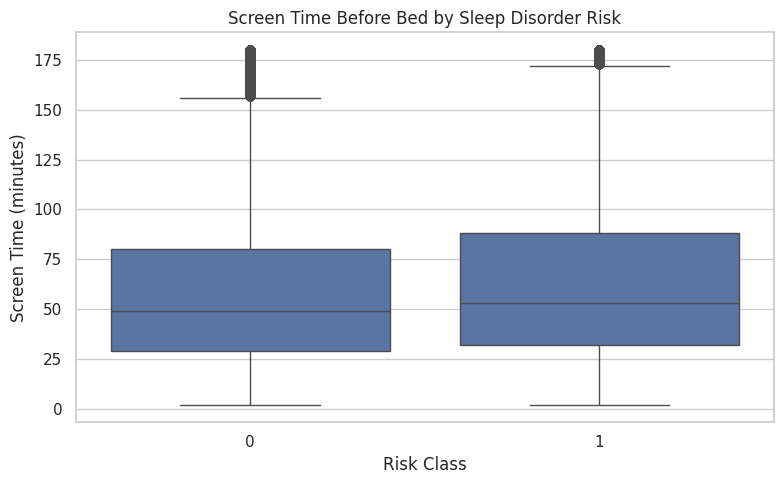

In [ ]:
# ============================================================
# 15. Screen time before bed by target
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_model,
    x="sleep_disorder_risk",
    y="screen_time_before_bed_mins"
)
plt.title("Screen Time Before Bed by Sleep Disorder Risk")
plt.xlabel("Risk Class")
plt.ylabel("Screen Time (minutes)")
plt.tight_layout()
plt.show()


## 6. Correlation analysis

Correlation is useful for identifying linear relationships between numeric variables and the binary target. It is **not** enough by itself to select the final model.

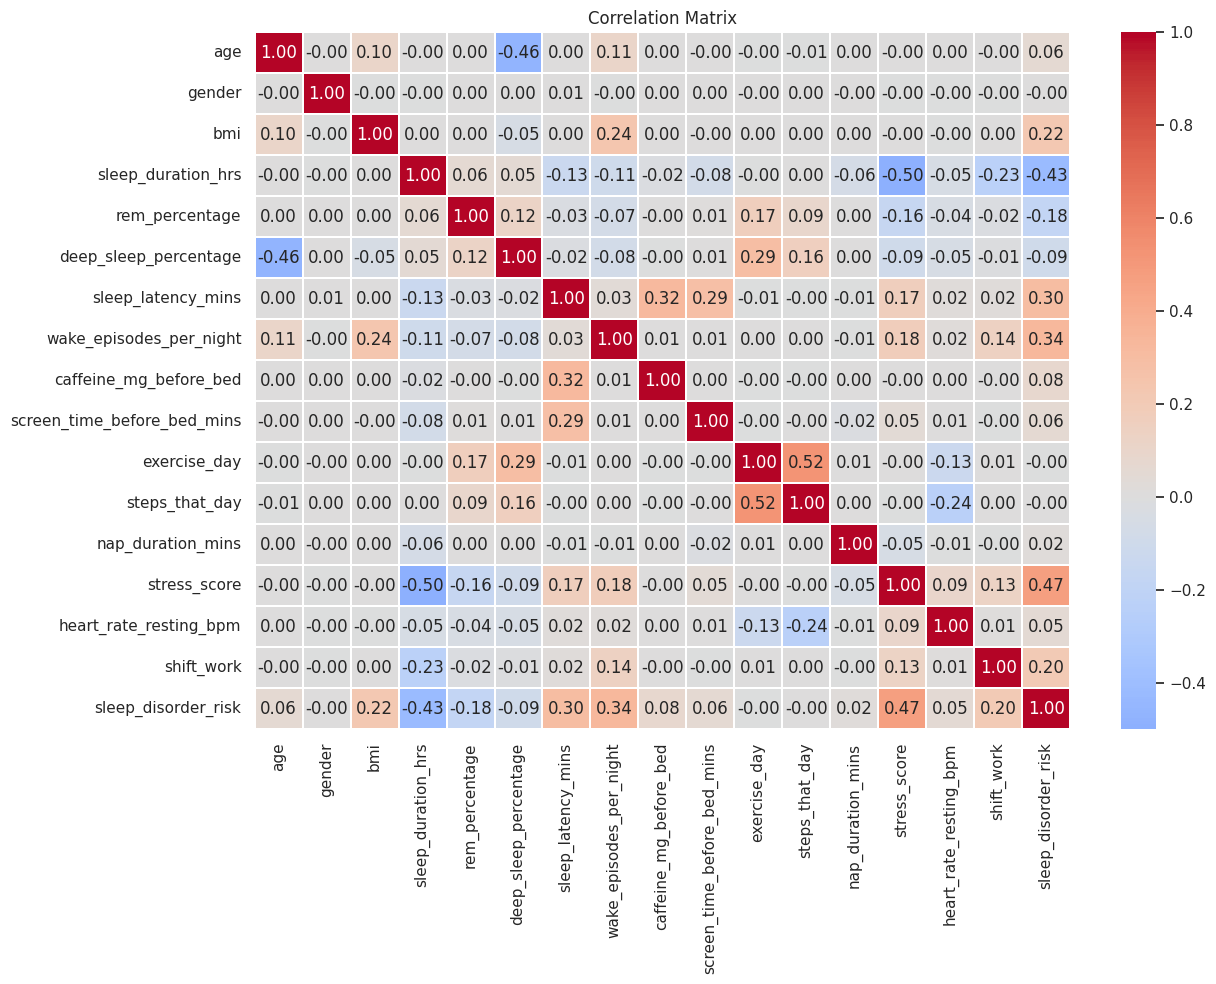

Correlation with target:


,correlation
sleep_disorder_risk,1.000000
stress_score,0.468132
wake_episodes_per_night,0.336365
sleep_latency_mins,0.300031
bmi,0.221970
shift_work,0.204450
caffeine_mg_before_bed,0.084590
age,0.062466
screen_time_before_bed_mins,0.060545
heart_rate_resting_bpm,0.045712


In [ ]:
# ============================================================
# 16. Correlation matrix
# ============================================================

corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Correlation with target:")
display(
    corr["sleep_disorder_risk"]
    .sort_values(ascending=False)
    .to_frame("correlation")
)


## 7. Outlier analysis

We inspect IQR-based outlier counts but do **not** automatically delete observations.

The dataset contains realistic behavioral ranges such as sleep duration, steps, caffeine, and screen time. Automatically deleting all IQR outliers could remove valid observations and change the problem unnecessarily.

In [ ]:
# ============================================================
# 17. IQR outlier report
# ============================================================

numeric_features = df_model.drop(columns=["sleep_disorder_risk"]).select_dtypes(
    include=np.number
).columns

outlier_rows = []

for col in numeric_features:
    q1 = df_model[col].quantile(0.25)
    q3 = df_model[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df_model[col] < lower) | (df_model[col] > upper)).sum())
    outlier_rows.append([col, lower, upper, count])

outlier_report = pd.DataFrame(
    outlier_rows,
    columns=["feature", "lower_bound", "upper_bound", "outlier_count"]
).sort_values("outlier_count", ascending=False)

display(outlier_report)


,feature,lower_bound,upper_bound,outlier_count
15,shift_work,0.00,0.00,8268
9,screen_time_before_bed_mins,-51.00,165.00,5678
8,caffeine_mg_before_bed,-120.00,200.00,2343
13,stress_score,1.80,9.80,2114
14,heart_rate_resting_bpm,48.50,84.50,1266
12,nap_duration_mins,-45.00,75.00,870
4,rem_percentage,11.10,29.50,761
3,sleep_duration_hrs,2.92,9.88,532
5,deep_sleep_percentage,8.70,31.90,391
6,sleep_latency_mins,-2.50,41.50,362


## 8. Train/test split

We use a **stratified 80/20 split** so the class proportions remain stable in training and testing.

Scaling is fitted only on the training data through a Pipeline. This avoids data leakage.

In [ ]:
# ============================================================
# 18. Prepare X and y
# ============================================================

X = df_model.drop(columns=["sleep_disorder_risk"])
y = df_model["sleep_disorder_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


X_train: (78420, 16)
X_test : (19606, 16)
y_train: (78420,)
y_test : (19606,)

Training target distribution:
sleep_disorder_risk
0    0.542
1    0.458
Name: proportion, dtype: float64

Testing target distribution:
sleep_disorder_risk
0    0.542
1    0.458
Name: proportion, dtype: float64


## 9. Baseline classification models

We train several models using the same train/test split.

For models affected by feature scale, `StandardScaler` is placed inside a Pipeline. Tree-based models do not require scaling.

In [ ]:
# ============================================================
# 19. Define models
# ============================================================

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=12,
        min_samples_leaf=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_features="sqrt",
        min_samples_leaf=2
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=150,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ),
}

print("Models ready:")
for name in models:
    print("-", name)


Models ready:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- AdaBoost


In [ ]:
# ============================================================
# 20. Train and evaluate baseline models
# ============================================================

results = []
trained_models = {}
test_probabilities = {}
test_predictions = {}

for name, model in models.items():
    print(f"Training: {name}")
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        test_prob = model.predict_proba(X_test)[:, 1]
    else:
        test_prob = None

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    precision = precision_score(y_test, test_pred, zero_division=0)
    recall = recall_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)
    auc = roc_auc_score(y_test, test_prob) if test_prob is not None else np.nan

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": auc
    })

    trained_models[name] = model
    test_predictions[name] = test_pred
    if test_prob is not None:
        test_probabilities[name] = test_prob

baseline_results = (
    pd.DataFrame(results)
    .sort_values(["F1", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(
    baseline_results.style.format({
        "Train Accuracy": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


Training: Logistic Regression
Training: KNN
Training: Decision Tree
Training: Random Forest
Training: AdaBoost


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.9926,0.8802,0.9172,0.8120,0.8614,0.9470
1,Decision Tree,0.8969,0.8706,0.9279,0.7781,0.8465,0.9290
2,AdaBoost,0.8560,0.8545,0.8503,0.8284,0.8392,0.9382
3,Logistic Regression,0.8188,0.8165,0.8103,0.7831,0.7965,0.8955
4,KNN,0.8570,0.8053,0.8315,0.7214,0.7725,0.8813


## 10. Optional XGBoost model

The original project used XGBoost. The cell below uses it when the package is installed.

If XGBoost is not installed in the local VS Code environment, the notebook will continue normally and report that XGBoost was skipped instead of crashing.

In [ ]:
# ============================================================
# 21. XGBoost — optional, error-safe
# ============================================================

try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    xgb_train_pred = xgb_model.predict(X_train)
    xgb_test_pred = xgb_model.predict(X_test)
    xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

    xgb_result = {
        "Model": "XGBoost",
        "Train Accuracy": accuracy_score(y_train, xgb_train_pred),
        "Test Accuracy": accuracy_score(y_test, xgb_test_pred),
        "Precision": precision_score(y_test, xgb_test_pred, zero_division=0),
        "Recall": recall_score(y_test, xgb_test_pred, zero_division=0),
        "F1": f1_score(y_test, xgb_test_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, xgb_test_prob)
    }

    results.append(xgb_result)
    trained_models["XGBoost"] = xgb_model
    test_predictions["XGBoost"] = xgb_test_pred
    test_probabilities["XGBoost"] = xgb_test_prob

    print("XGBoost trained successfully.")

except ImportError:
    print(
        "XGBoost is not installed. "
        "The rest of the project remains fully functional."
    )


XGBoost trained successfully.


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.9081,0.8806,0.9068,0.8242,0.8635,0.9491
1,Random Forest,0.9926,0.8802,0.9172,0.8120,0.8614,0.9470
2,Decision Tree,0.8969,0.8706,0.9279,0.7781,0.8465,0.9290
3,AdaBoost,0.8560,0.8545,0.8503,0.8284,0.8392,0.9382
4,Logistic Regression,0.8188,0.8165,0.8103,0.7831,0.7965,0.8955
5,KNN,0.8570,0.8053,0.8315,0.7214,0.7725,0.8813


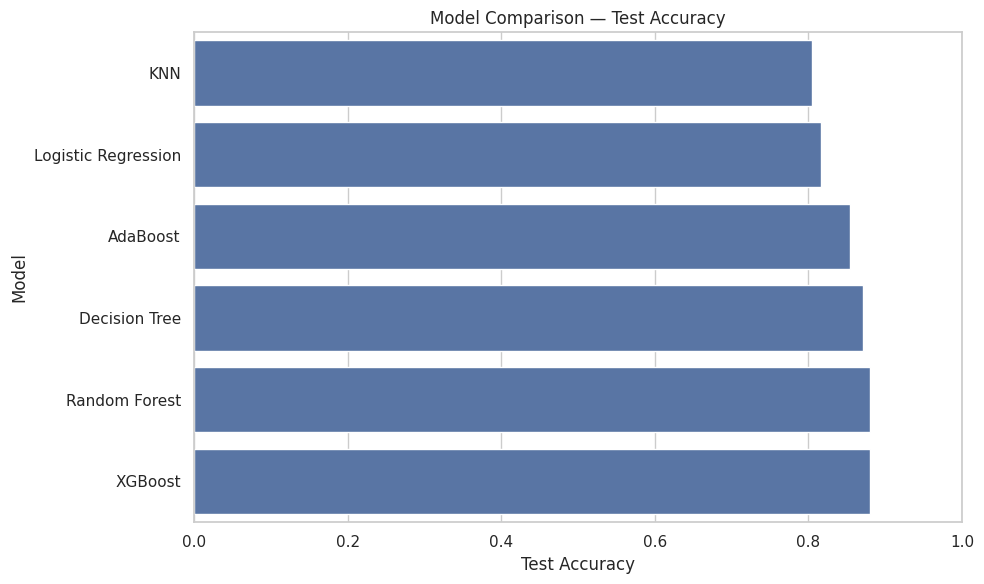

In [ ]:
# ============================================================
# 22. Complete model comparison
# ============================================================

all_results = (
    pd.DataFrame(results)
    .sort_values(["F1", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(
    all_results.style.format({
        "Train Accuracy": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

plt.figure(figsize=(10, 6))
plot_df = all_results.sort_values("Test Accuracy", ascending=True)
sns.barplot(data=plot_df, x="Test Accuracy", y="Model")
plt.xlim(0, 1)
plt.title("Model Comparison — Test Accuracy")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


## 11. Hyperparameter tuning

The baseline Random Forest from the original notebook showed a very high training accuracy and lower test accuracy, which is a sign of overfitting.

We therefore tune a Random Forest using stratified cross-validation and a limited randomized search.

In [ ]:
# ============================================================
# 23. Random Forest hyperparameter tuning
# ============================================================

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}
Best CV F1: 0.8622


In [ ]:
# ============================================================
# 24. Evaluate tuned Random Forest
# ============================================================

best_rf_train_pred = best_rf.predict(X_train)
best_rf_test_pred = best_rf.predict(X_test)
best_rf_test_prob = best_rf.predict_proba(X_test)[:, 1]

tuned_rf_result = {
    "Model": "Tuned Random Forest",
    "Train Accuracy": accuracy_score(y_train, best_rf_train_pred),
    "Test Accuracy": accuracy_score(y_test, best_rf_test_pred),
    "Precision": precision_score(y_test, best_rf_test_pred, zero_division=0),
    "Recall": recall_score(y_test, best_rf_test_pred, zero_division=0),
    "F1": f1_score(y_test, best_rf_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, best_rf_test_prob)
}

results_with_tuning = (
    pd.concat(
        [pd.DataFrame(results), pd.DataFrame([tuned_rf_result])],
        ignore_index=True
    )
    .sort_values(["F1", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(
    results_with_tuning.style.format({
        "Train Accuracy": "{:.4f}",
        "Test Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.9081,0.8806,0.9068,0.8242,0.8635,0.9491
1,Tuned Random Forest,0.9751,0.8806,0.9155,0.8148,0.8622,0.9468
2,Random Forest,0.9926,0.8802,0.9172,0.8120,0.8614,0.9470
3,Decision Tree,0.8969,0.8706,0.9279,0.7781,0.8465,0.9290
4,AdaBoost,0.8560,0.8545,0.8503,0.8284,0.8392,0.9382
5,Logistic Regression,0.8188,0.8165,0.8103,0.7831,0.7965,0.8955
6,KNN,0.8570,0.8053,0.8315,0.7214,0.7725,0.8813


## 12. Classification reports

Accuracy alone is not enough. The classification report gives:
- Precision
- Recall
- F1-score
- Support

Recall is especially useful when missing an at-risk person is important.

In [ ]:
# ============================================================
# 25. Classification reports for the strongest models
# ============================================================

for model_name in results_with_tuning["Model"].head(3):
    if model_name == "Tuned Random Forest":
        pred = best_rf_test_pred
    else:
        pred = test_predictions[model_name]

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(
        y_test,
        pred,
        target_names=["Healthy (0)", "At Risk (1)"],
        zero_division=0
    ))


XGBoost
              precision    recall  f1-score   support

 Healthy (0)       0.86      0.93      0.89     10619
 At Risk (1)       0.91      0.82      0.86      8987

    accuracy                           0.88     19606
   macro avg       0.88      0.88      0.88     19606
weighted avg       0.88      0.88      0.88     19606

Tuned Random Forest
              precision    recall  f1-score   support

 Healthy (0)       0.86      0.94      0.89     10619
 At Risk (1)       0.92      0.81      0.86      8987

    accuracy                           0.88     19606
   macro avg       0.89      0.88      0.88     19606
weighted avg       0.88      0.88      0.88     19606

Random Forest
              precision    recall  f1-score   support

 Healthy (0)       0.85      0.94      0.89     10619
 At Risk (1)       0.92      0.81      0.86      8987

    accuracy                           0.88     19606
   macro avg       0.89      0.87      0.88     19606
weighted avg       0.88      0.8

## 13. Confusion matrices

A confusion matrix shows:
- True Negatives
- False Positives
- False Negatives
- True Positives

For risk prediction, false negatives are particularly important because they represent at-risk cases predicted as healthy.

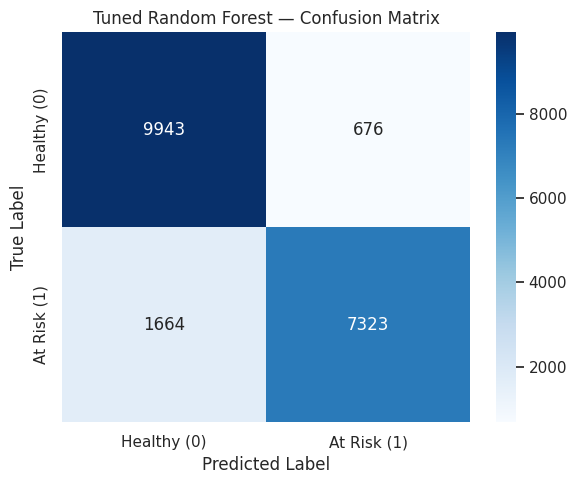

Confusion matrix:
[[9943  676]
 [1664 7323]]


In [ ]:
# ============================================================
# 26. Confusion matrix for tuned Random Forest
# ============================================================

cm = confusion_matrix(y_test, best_rf_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy (0)", "At Risk (1)"],
    yticklabels=["Healthy (0)", "At Risk (1)"]
)
plt.title("Tuned Random Forest — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
print(cm)


## 14. ROC curves and ROC-AUC

ROC-AUC measures how well the model separates the two classes across classification thresholds.

Higher AUC means better ranking/separation ability.

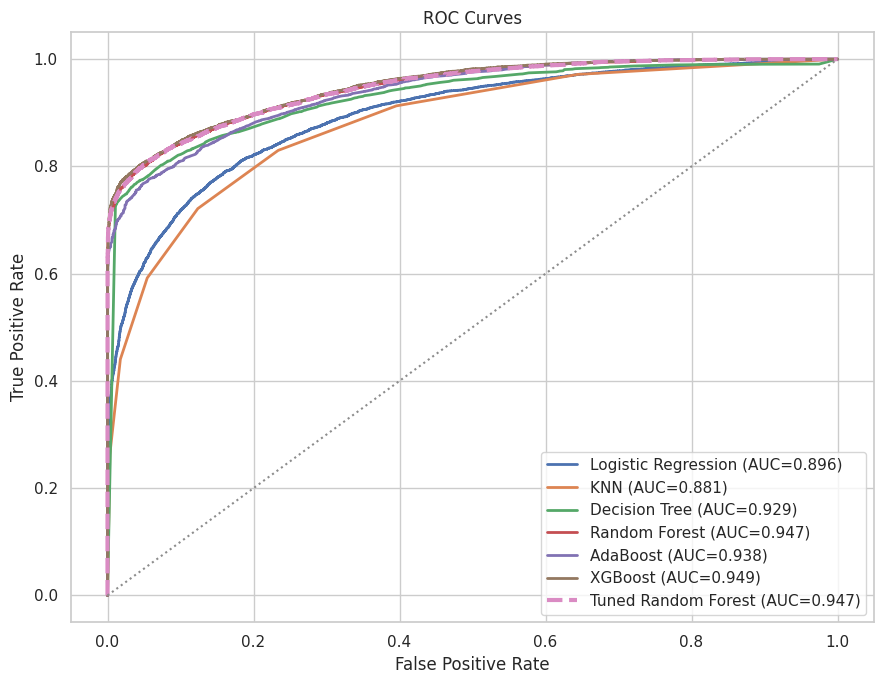

In [ ]:
# ============================================================
# 27. ROC curves
# ============================================================

plt.figure(figsize=(9, 7))

for name, prob in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_value:.3f})")

fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf_test_prob)
auc_rf = roc_auc_score(y_test, best_rf_test_prob)
plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=3,
    linestyle="--",
    label=f"Tuned Random Forest (AUC={auc_rf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Feature importance

Random Forest provides a model-based estimate of feature importance.

These values indicate which features the fitted tree ensemble relied on most for prediction. They should be interpreted as model importance, not as proof of causation.

,Feature,Importance
3,sleep_duration_hrs,0.280791
13,stress_score,0.193245
2,bmi,0.101680
7,wake_episodes_per_night,0.100320
6,sleep_latency_mins,0.099841
4,rem_percentage,0.051079
11,steps_that_day,0.027135
0,age,0.026733
5,deep_sleep_percentage,0.026367
9,screen_time_before_bed_mins,0.025016


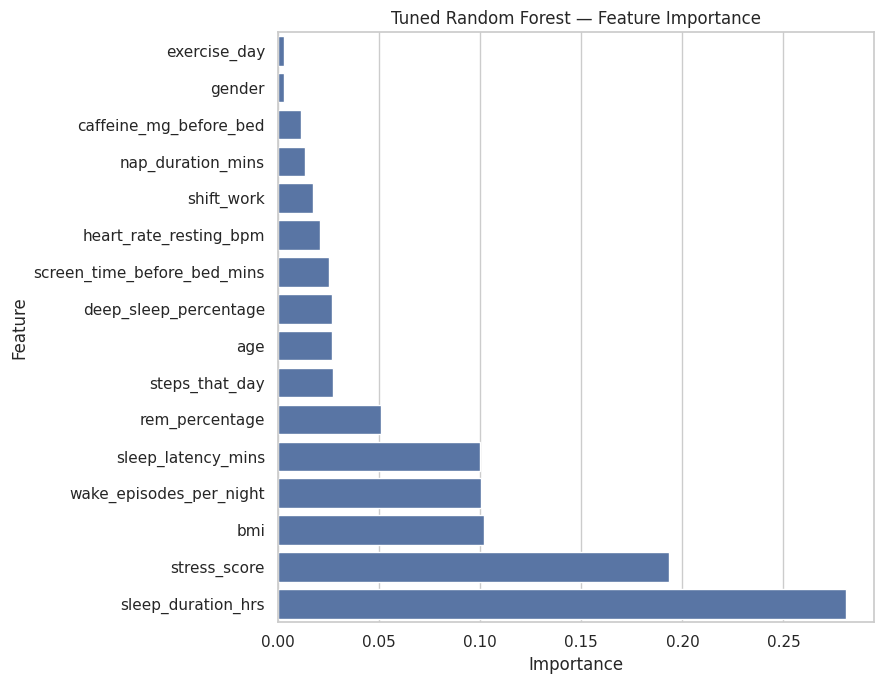

In [ ]:
# ============================================================
# 28. Tuned Random Forest feature importance
# ============================================================

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(9, 7))
sns.barplot(
    data=importance_df.sort_values("Importance", ascending=True),
    x="Importance",
    y="Feature"
)
plt.title("Tuned Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 16. Logistic Regression coefficients

For comparison, Logistic Regression gives signed coefficients.

- Positive coefficient → increases the model's log-odds toward class 1.
- Negative coefficient → pushes the prediction toward class 0.

The coefficients are based on standardized features in the Pipeline.

,Feature,Coefficient,Absolute Coefficient
13,stress_score,1.024420,1.024420
3,sleep_duration_hrs,-0.861055,0.861055
6,sleep_latency_mins,0.816558,0.816558
7,wake_episodes_per_night,0.726321,0.726321
2,bmi,0.658686,0.658686
4,rem_percentage,-0.393743,0.393743
15,shift_work,0.346084,0.346084
9,screen_time_before_bed_mins,-0.078511,0.078511
12,nap_duration_mins,0.071482,0.071482
0,age,0.062316,0.062316


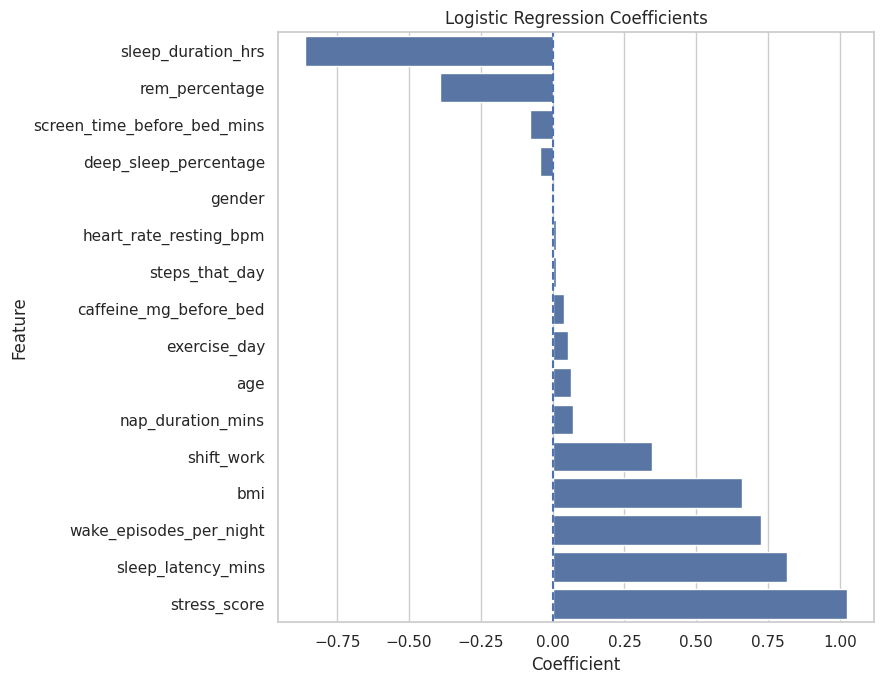

In [ ]:
# ============================================================
# 29. Logistic Regression coefficients
# ============================================================

logistic_model = trained_models["Logistic Regression"]
logistic_estimator = logistic_model.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_estimator.coef_[0]
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute Coefficient", ascending=False)

display(coef_df)

plt.figure(figsize=(9, 7))
coef_plot = coef_df.sort_values("Coefficient")
sns.barplot(
    data=coef_plot,
    x="Coefficient",
    y="Feature"
)
plt.axvline(0, linestyle="--")
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 17. Final model selection

The final model is selected using **F1-score first** and **ROC-AUC second**.

This avoids choosing a model based only on accuracy and gives balanced attention to precision and recall.

In [ ]:
# ============================================================
# 30. Select final model
# ============================================================

selection_table = results_with_tuning.copy()

best_row = selection_table.sort_values(
    ["F1", "ROC-AUC", "Test Accuracy"],
    ascending=False
).iloc[0]

best_model_name = best_row["Model"]

if best_model_name == "Tuned Random Forest":
    final_model = best_rf
    final_pred = best_rf_test_pred
    final_prob = best_rf_test_prob
else:
    final_model = trained_models[best_model_name]
    final_pred = test_predictions[best_model_name]
    final_prob = test_probabilities.get(best_model_name)

print("FINAL MODEL:", best_model_name)
display(best_row.to_frame("value"))


FINAL MODEL: XGBoost


,value
Model,XGBoost
Train Accuracy,0.908097
Test Accuracy,0.880598
Precision,0.906832
Recall,0.82419
F1,0.863538
ROC-AUC,0.949055


## 18. Example prediction

This example uses one real test record.

The model predicts:
- `0` → Healthy
- `1` → At Risk

The probability gives the model's estimated probability for class 1.

In [ ]:
# ============================================================
# 31. Example prediction
# ============================================================

sample_index = X_test.index[0]
sample = X_test.loc[[sample_index]]
actual = int(y_test.loc[sample_index])

prediction = int(final_model.predict(sample)[0])

if hasattr(final_model, "predict_proba"):
    probability = float(final_model.predict_proba(sample)[0, 1])
else:
    probability = np.nan

print("Actual class      :", actual)
print("Predicted class   :", prediction)

if not np.isnan(probability):
    print(f"At-risk probability: {probability:.2%}")

print(
    "Prediction meaning:",
    "Healthy" if prediction == 0 else "At Risk"
)


Actual class      : 1
Predicted class   : 1
At-risk probability: 99.99%
Prediction meaning: At Risk


## 19. Final project summary

### What was completed

1. Loaded and inspected the 100,000-row sleep-health dataset.
2. Checked missing values and duplicates.
3. Applied the team's gender preprocessing.
4. Converted the original sleep-disorder categories into binary risk.
5. Applied the team's feature-selection decisions.
6. Performed EDA and correlation analysis.
7. Checked potential IQR outliers without blindly deleting valid observations.
8. Created a stratified 80/20 train/test split.
9. Used scaling correctly inside Pipelines where needed.
10. Trained multiple classification algorithms.
11. Compared accuracy, precision, recall, F1, and ROC-AUC.
12. Tuned Random Forest to address overfitting.
13. Generated confusion matrix and ROC curves.
14. Analyzed Random Forest feature importance.
15. Examined Logistic Regression coefficients.
16. Selected a final model using F1 and ROC-AUC.
17. Demonstrated an example prediction.

### Important interpretation

This project predicts **risk status**, not a medical diagnosis. A model prediction should be treated as a machine-learning output, not a clinical conclusion.

In [ ]:
# ============================================================
# 32. Final compact report
# ============================================================

print("=" * 80)
print("FINAL PROJECT REPORT")
print("=" * 80)
print(f"Dataset shape after preprocessing: {df_model.shape}")
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")
print(f"Final model     : {best_model_name}")
print(f"Test Accuracy   : {best_row['Test Accuracy']:.4f}")
print(f"Precision       : {best_row['Precision']:.4f}")
print(f"Recall          : {best_row['Recall']:.4f}")
print(f"F1-score        : {best_row['F1']:.4f}")
print(f"ROC-AUC         : {best_row['ROC-AUC']:.4f}")
print("=" * 80)


FINAL PROJECT REPORT
Dataset shape after preprocessing: (98026, 17)
Training samples: 78,420
Testing samples : 19,606
Final model     : XGBoost
Test Accuracy   : 0.8806
Precision       : 0.9068
Recall          : 0.8242
F1-score        : 0.8635
ROC-AUC         : 0.9491
